In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../data/customers.csv')

In [3]:
print("Анализ данных")
print(df.info())

Анализ данных
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               10000 non-null  object 
 1   Product_ID                10000 non-null  object 
 2   Transaction_ID            10000 non-null  object 
 3   Purchase_Frequency        10000 non-null  int64  
 4   Average_Order_Value       10000 non-null  float64
 5   Most_Frequent_Category    10000 non-null  object 
 6   Time_Between_Purchases    10000 non-null  int64  
 7   Region                    10000 non-null  object 
 8   Churn_Probability         10000 non-null  float64
 9   Lifetime_Value            10000 non-null  float64
 10  Launch_Date               10000 non-null  object 
 11  Peak_Sales_Date           10000 non-null  object 
 12  Season                    10000 non-null  object 
 13  Preferred_Purchase_Times  10000 non-null  object

 0   Customer_ID - уникальный идентификатор покупателя (категориальный)
 1   Product_ID - какой товар чаще всего покупает (категориальный)
 2   Transaction_ID - уникальный номер покупки (категориальный)
 3   Purchase_Frequency - частота покупок (числовой)
 4   Average_Order_Value  - средний чек (числовой)
 5   Most_Frequent_Category - любимая категория (категориальный)
 6   Time_Between_Purchases - время между покупками  (числовой)
 7   Region - регион (категориальный)
 8   Churn_Probability - вероятность оттока (числовой)
 9   Lifetime_Value - сколько денег принес за все время (числовой)
 10  Launch_Date - дата регистрации (категориальный)
 11  Peak_Sales_Date - когда покупал больше всего (категориальный)
 12  Season - сезон пиковых покупок  (категориальный)
 13  Preferred_Purchase_Times - время покупок (категориальный)
 14  Retention_Strategy - какую акцию ему предлагали (категориальный)

НЕ НУЖНО: ????

Ключевые признаки:
Purchase_Frequency - частота покупок
Average_Order_Value - средний чек
Lifetime_Value - сколько денег принес за все время

In [40]:
numeric_features = ['Purchase_Frequency', 'Average_Order_Value', 
                    'Time_Between_Purchases', 'Churn_Probability', 'Lifetime_Value']

categorical_features = ['Most_Frequent_Category', 'Region', 'Launch_Date', 
                        'Peak_Sales_Date', 'Season', 'Preferred_Purchase_Times', 
                        'Retention_Strategy']

# ID-шники (не участвуют в обучении)
id_columns = ['Customer_ID', 'Product_ID', 'Transaction_ID']

print(f"\nЧисловые признаки: {len(numeric_features)}")
print(f"Категориальные признаки: {len(categorical_features)}")
print(f"ID колонки: {len(id_columns)}")


Числовые признаки: 5
Категориальные признаки: 7
ID колонки: 3


In [42]:
print("\nПервые 3 строки:")
df.head(3)


Первые 3 строки:


,Customer_ID,Product_ID,Transaction_ID,Purchase_Frequency,Average_Order_Value,Most_Frequent_Category,Time_Between_Purchases,Region,Churn_Probability,Lifetime_Value,...,Season,Preferred_Purchase_Times,Retention_Strategy,Most_Frequent_Category_encoded,Region_encoded,Launch_Date_encoded,Peak_Sales_Date_encoded,Season_encoded,Preferred_Purchase_Times_encoded,Retention_Strategy_encoded
0,CUST_9HOS83,PROD_IK97D1,TRANS_II1DZG,17,172.57,Electronics,45,South America,0.98,952.81,...,Winter,Afternoon,Loyalty Program,1,3,73,253,3,0,2
1,CUST_AJU17N,PROD_UNN7KP,TRANS_9HJF7I,10,64.89,Clothing,6,South America,0.66,5427.51,...,Spring,Afternoon,Discount,0,3,1018,1,1,0,0
2,CUST_11XNYF,PROD_0XEW2W,TRANS_OT96OM,3,120.38,Sports,23,Asia,0.60,3994.80,...,Winter,Evening,Loyalty Program,3,0,699,95,3,1,2


АНАЛИЗ ЧИСЛОВЫХ ПРИЗНАКОВ

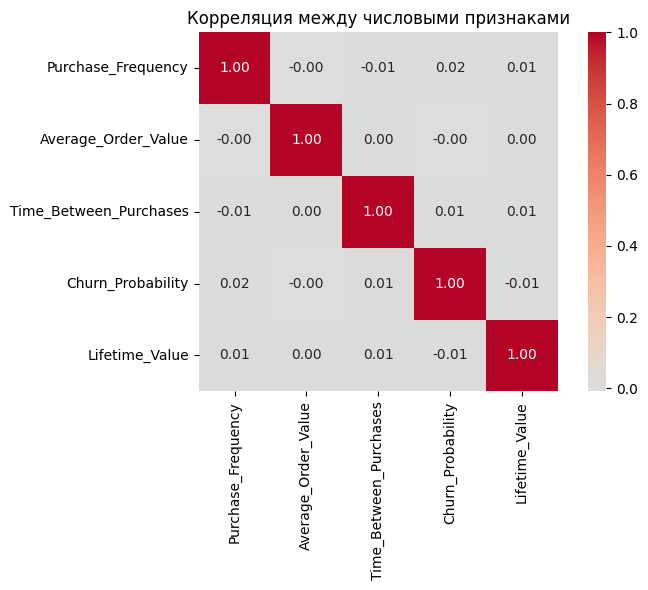

In [6]:
# Корреляция между числовыми признаками
corr_matrix = df[numeric_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Корреляция между числовыми признаками')
plt.tight_layout()
plt.savefig('../correlation.png')
plt.show()

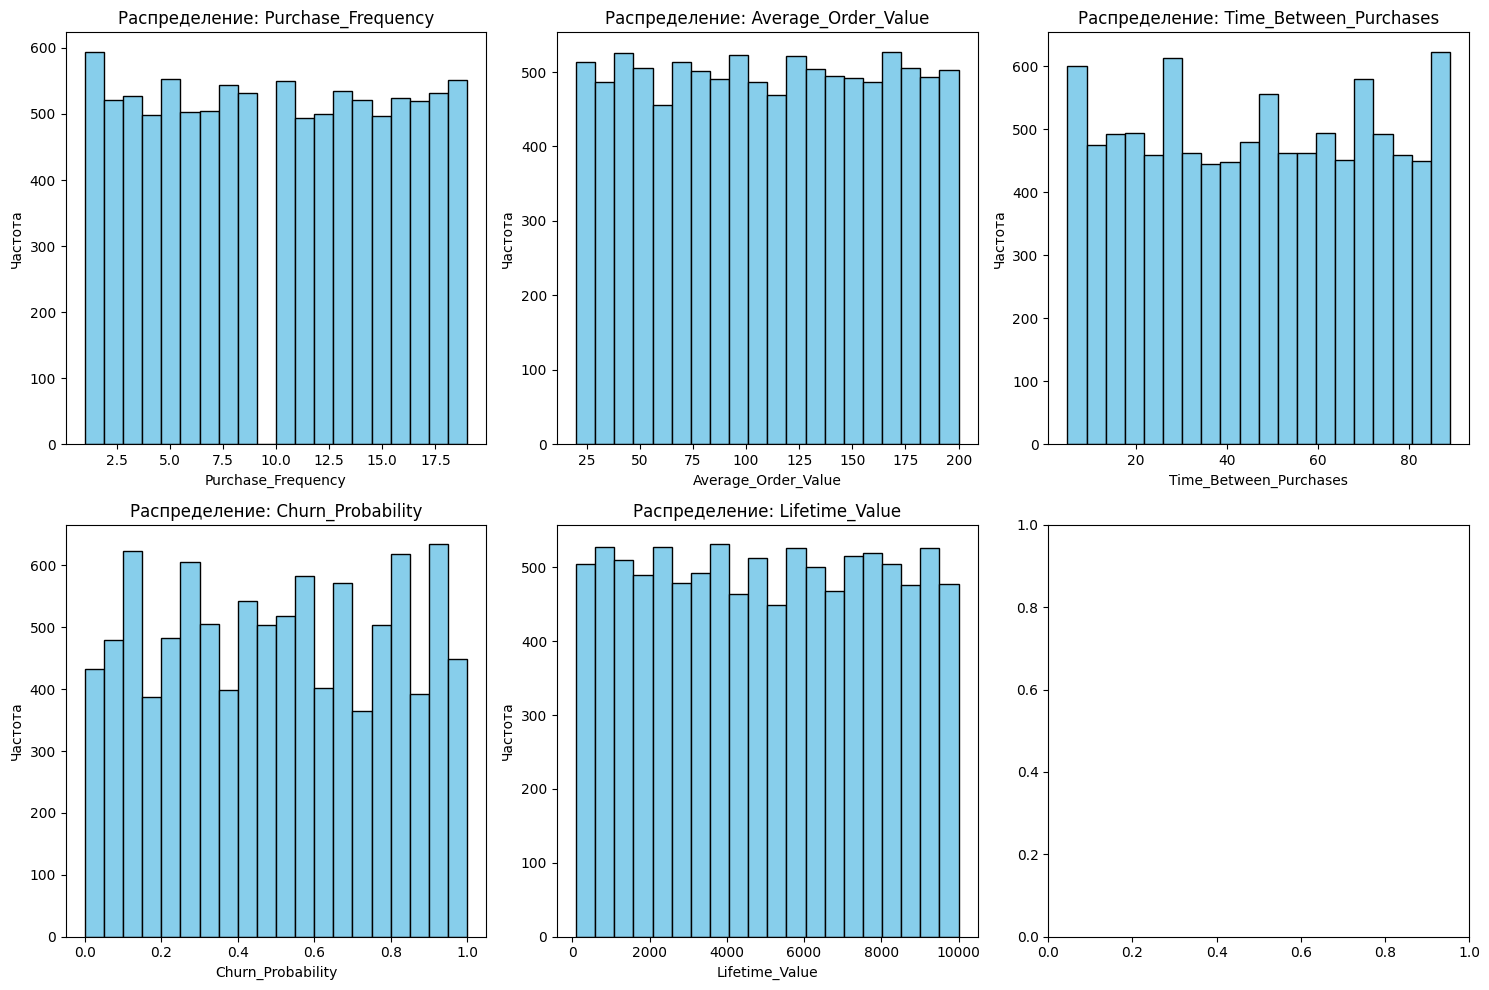

In [7]:
# Гистограммы числовых признаков
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, feature in enumerate(numeric_features):
    row, col = i // 3, i % 3
    axes[row, col].hist(df[feature].dropna(), bins=20, edgecolor='black', color='skyblue')
    axes[row, col].set_title(f'Распределение: {feature}')
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('Частота')
plt.tight_layout()
plt.savefig('../distributions.png')
plt.show()

КОДИРОВКА ДАННЫХ

In [88]:
# продублировала для удобства, чтобы была возможность редактировать
numeric_features = ['Purchase_Frequency', 'Average_Order_Value', 
                    'Time_Between_Purchases', 'Churn_Probability', 'Lifetime_Value']

categorical_features = ['Season', 'Preferred_Purchase_Times', 
                        'Retention_Strategy']

In [90]:
df_encoded = df.copy()

for col in categorical_features:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    print(f"Закодирована колонка: {col}")

feature_cols = numeric_features + categorical_features

X = df_encoded[feature_cols]
print(f"\nПризнаков: {X.shape[1]}")
X.head(3)

Закодирована колонка: Season
Закодирована колонка: Preferred_Purchase_Times
Закодирована колонка: Retention_Strategy

Признаков: 8


,Purchase_Frequency,Average_Order_Value,Time_Between_Purchases,Churn_Probability,Lifetime_Value,Season,Preferred_Purchase_Times,Retention_Strategy
0,17,172.57,45,0.98,952.81,3,0,2
1,10,64.89,6,0.66,5427.51,1,0,0
2,3,120.38,23,0.60,3994.80,3,1,2


ПОДГОТОВКА ДАННЫХ ДЛЯ КЛАСТЕРИЗАЦИИ

In [91]:
# масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

ВЫБОР ОПТИМАЛЬНОГО ЧИСЛА КЛАСТЕРОВ

In [92]:
inertias = []
silhouette_scores = []
K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"K={k}: Инерция={kmeans.inertia_:.0f}, Silhouette={score:.3f}")

K=2: Инерция=71980, Silhouette=0.100
K=3: Инерция=67085, Silhouette=0.090
K=4: Инерция=63900, Silhouette=0.090
K=5: Инерция=61059, Silhouette=0.085
K=6: Инерция=58632, Silhouette=0.087
K=7: Инерция=56417, Silhouette=0.089
K=8: Инерция=54601, Silhouette=0.090


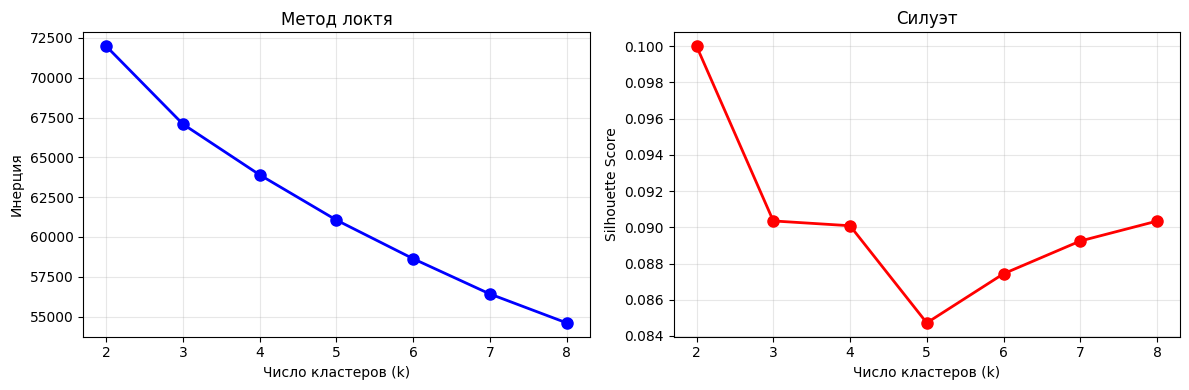

In [93]:
# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Число кластеров (k)')
ax1.set_ylabel('Инерция')
ax1.set_title('Метод локтя')
ax1.grid(True, alpha=0.3)

ax2.plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Число кластеров (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Силуэт')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../elbow_method.png')
plt.show()

Оптимальное число кластеров = 2 по всем методам

In [120]:
optimal_k = 2

ОБУЧЕНИЕ МОДЕЛЕЙ КЛАСТЕРИЗАЦИИ

In [121]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

K‑Means — это алгоритм кластеризации, который разбивает данные на K групп (кластеров). Алгоритм состоит из следующих шагов:

Выбрать число кластеров K.

Инициализировать центры кластеров — выбрать K случайных точек из данных.

Отнести каждую точку к ближайшему центру (по евклидову расстоянию).

Пересчитать центры — взять среднее арифметическое всех точек, попавших в кластер.

Повторять шаги 3–4, пока центры не перестанут меняться/алгоритм сойдётся.

Группирует объекты по схожести.
Минимизирует внутрикластерную дисперсию — делает точки внутри кластера максимально похожими
Максимизирует межкластерные расстояния — кластеры получаютсятразделёнными.
Ищет центры кластеров (центроиды).

1. KMEANS
МЕТРИКИ K-MEANS
Компактность (WCSS) = 71980
Отделимость (BSS) = 8020
Силуэт = 0.1000

Распределение по кластерам:
  Кластер 0: 4945 (49.5%)
  Кластер 1: 5055 (50.5%)


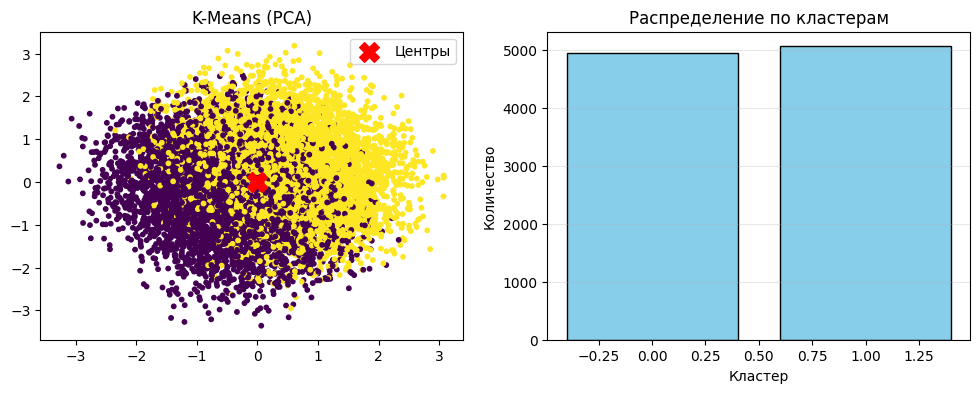

In [122]:
# KMEANS
print("1. KMEANS")

kmeans = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42) #количество кластеров, способ выбора начальных центров кластеров, количество запусков=10
kmeans_labels = kmeans.fit_predict(X_scaled)

# Метрики
print("МЕТРИКИ K-MEANS")
print(f"Компактность (WCSS) = {kmeans.inertia_:.0f}") #сумма квадратов расстояний от каждой точки до центра своего кластера.
centers = kmeans.cluster_centers_
global_mean = X_scaled.mean(axis=0)
bss = sum((kmeans_labels == i).sum() * np.sum((centers[i] - global_mean)**2) for i in range(optimal_k))
print(f"Отделимость (BSS) = {bss:.0f}")
print(f"Силуэт = {silhouette_score(X_scaled, kmeans_labels):.4f}")


# Распределение
counts = pd.Series(kmeans_labels).value_counts().sort_index()
print("\nРаспределение по кластерам:")
for c in counts.index:
    print(f"  Кластер {c}: {counts[c]} ({counts[c]/len(kmeans_labels)*100:.1f}%)")

# PCA визуализация
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels, cmap='viridis', s=10)
plt.scatter(centers[:,0], centers[:,1], marker='X', c='red', s=200, label='Центры')
plt.title('K-Means (PCA)')
plt.legend()

plt.subplot(1,2,2)
plt.bar(counts.index, counts.values, color='skyblue', edgecolor='black')
plt.xlabel('Кластер')
plt.ylabel('Количество')
plt.title('Распределение по кластерам')
plt.grid(axis='y', alpha=0.3)
plt.show()

плохая модель, силуэт = 0,1. центроиды не отделены, очень большая накладка кластеров друг на друга.

Модель Agglomerative Clustering (иерархическая) начинает с того, что каждая точка — это отдельный кластер. Затем алгоритм шаг за шагом объединяет самые похожие кластеры, пока не останется заданное количество кластеров.

МЕТРИКИ AGGLOMERATIVE
Компактность (WCSS) = 75876
Отделимость (BSS) = 4124
Силуэт = 0.0527

Распределение по кластерам:
  Кластер 0: 4739 (47.4%)
  Кластер 1: 5261 (52.6%)


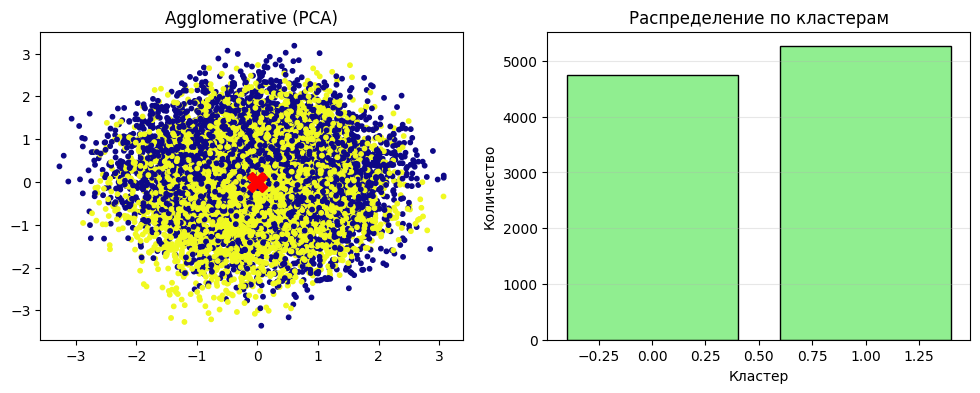

In [123]:
# МОДЕЛЬ AGGLOMERATIVE CLUSTERING

agg = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward') #число кластеров, метод объединения кластеров
agg_labels = agg.fit_predict(X_scaled)

# Метрики
print("МЕТРИКИ AGGLOMERATIVE")

centers_agg = np.array([X_scaled[agg_labels == i].mean(axis=0) for i in range(optimal_k)])
wcss_agg = sum(np.sum((X_scaled[agg_labels == i] - centers_agg[i])**2) for i in range(optimal_k))
bss_agg = sum((agg_labels == i).sum() * np.sum((centers_agg[i] - X_scaled.mean(axis=0))**2) for i in range(optimal_k))
print(f"Компактность (WCSS) = {wcss_agg:.0f}")
print(f"Отделимость (BSS) = {bss_agg:.0f}")
print(f"Силуэт = {silhouette_score(X_scaled, agg_labels):.4f}")

# Распределение
counts_agg = pd.Series(agg_labels).value_counts().sort_index()
print("\nРаспределение по кластерам:")
for c in counts_agg.index:
    print(f"  Кластер {c}: {counts_agg[c]} ({counts_agg[c]/len(agg_labels)*100:.1f}%)")

# Визуализация
plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.scatter(X_pca[:,0], X_pca[:,1], c=agg_labels, cmap='plasma', s=10)
plt.scatter(centers[:,0], centers[:,1], marker='X', c='red', s=200, label='Центры')

plt.title('Agglomerative (PCA)')

plt.subplot(1,2,2)
plt.bar(counts_agg.index, counts_agg.values, color='lightgreen', edgecolor='black')
plt.xlabel('Кластер')
plt.ylabel('Количество')
plt.title('Распределение по кластерам')
plt.grid(axis='y', alpha=0.3)
plt.show()

модель хуже, чем KMeans, большое перекрытие кластеров, центры наложены. силуэт еще меньше.

Модель DBSCAN - это метод кластеризации, основанный на плотности точек. Алгоритм ищет места, где точки расположены плотно (близко друг к другу), и объединяет их в кластеры. Точки, которые находятся в разреженных областях, считаются шумом (метка -1).

eps - максимальное расстояние, на котором две точки считаются соседями. Чем меньше eps, тем больше кластеров и шума. min_samples - минимальное количество соседей в радиусе eps, чтобы точка стала ядром кластера.

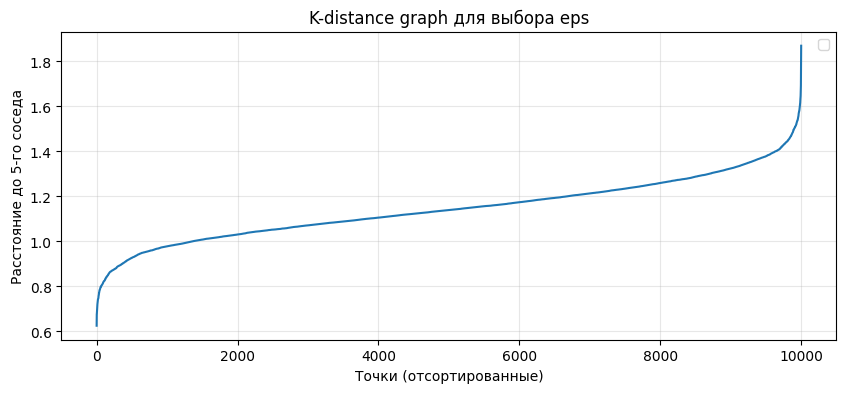

In [108]:
# DBSCAN

# K-distance graph для выбора eps
neigh = NearestNeighbors(n_neighbors=5)
nbrs = neigh.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)
distances = np.sort(distances[:, 4])  # Расстояние до 5-го соседа

plt.figure(figsize=(10, 4))
plt.plot(distances)
plt.title('K-distance graph для выбора eps')
plt.xlabel('Точки (отсортированные)')
plt.ylabel('Расстояние до 5-го соседа')
plt.grid(alpha=0.3)

# Находим точку изгиба (elbow)
# Берем расстояние на 80-90 перцентиле
eps_candidate = np.percentile(distances, 85)
plt.legend()
plt.show()

In [109]:
best_silhouette = -1
best_eps = None
best_min_samples = None
best_labels = None

# Диапазон параметров
eps_values = [0.4, 0.5, 0.6, 0.7, 0.8]
min_samples_values = [3, 5, 7, 10]

for eps in eps_values:
    for min_samples in min_samples_values:
        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_scaled)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        
        if n_clusters >= 2:
            mask = labels != -1
            sil = silhouette_score(X_scaled[mask], labels[mask])
            print(f"eps={eps}, min_samples={min_samples}: кластеров={n_clusters}, силуэт={sil:.3f}")
            
            if sil > best_silhouette:
                best_silhouette = sil
                best_params = (eps, min_samples)
        else:
            print(f"eps={eps}, min_samples={min_samples}: кластеров={n_clusters}")

print(f"\nЛучший: eps={best_params[0]}, min_samples={best_params[1]}, силуэт={best_silhouette:.3f}")

eps=0.4, min_samples=3: кластеров=4, силуэт=0.862
eps=0.4, min_samples=5: кластеров=0
eps=0.4, min_samples=7: кластеров=0
eps=0.4, min_samples=10: кластеров=0
eps=0.5, min_samples=3: кластеров=20, силуэт=0.771
eps=0.5, min_samples=5: кластеров=0
eps=0.5, min_samples=7: кластеров=0
eps=0.5, min_samples=10: кластеров=0
eps=0.6, min_samples=3: кластеров=106, силуэт=0.650
eps=0.6, min_samples=5: кластеров=0
eps=0.6, min_samples=7: кластеров=0
eps=0.6, min_samples=10: кластеров=0
eps=0.7, min_samples=3: кластеров=313, силуэт=0.523
eps=0.7, min_samples=5: кластеров=7, силуэт=0.666
eps=0.7, min_samples=7: кластеров=0
eps=0.7, min_samples=10: кластеров=0
eps=0.8, min_samples=3: кластеров=662, силуэт=0.387
eps=0.8, min_samples=5: кластеров=46, силуэт=0.571
eps=0.8, min_samples=7: кластеров=1
eps=0.8, min_samples=10: кластеров=0

Лучший: eps=0.4, min_samples=3, силуэт=0.862


eps=0.4, min_samples=3
Кластеров: 4, шум: 9988 (99.9%)
Силуэт (без шума): 0.8619

Распределение по кластерам (-1 = шум):
  -1: 9988
  0: 3
  1: 3
  2: 3
  3: 3


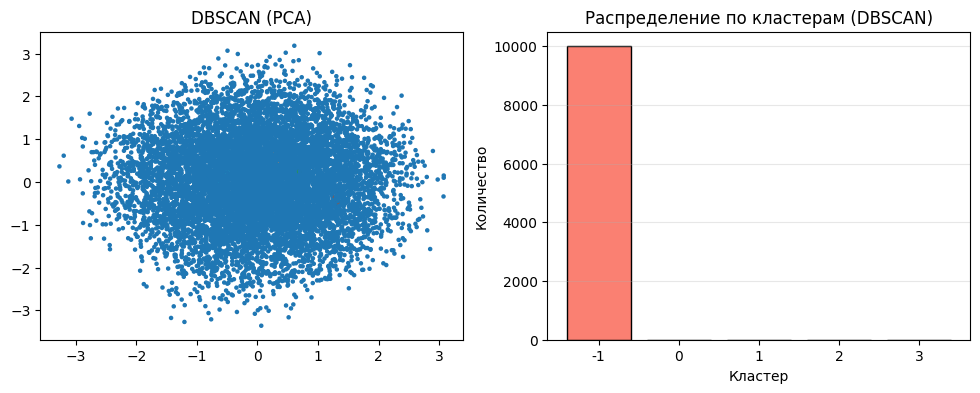

In [110]:
eps = 0.4
min_samples = 3

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Результаты
n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = sum(dbscan_labels == -1)
print(f"eps={eps}, min_samples={min_samples}")
print(f"Кластеров: {n_clusters_db}, шум: {n_noise} ({n_noise/len(dbscan_labels)*100:.1f}%)")

if n_clusters_db > 1:
    sil_db = silhouette_score(X_scaled[dbscan_labels != -1], dbscan_labels[dbscan_labels != -1])
    print(f"Силуэт (без шума): {sil_db:.4f}")

# Распределение
counts_db = pd.Series(dbscan_labels).value_counts().sort_index()
print("\nРаспределение по кластерам (-1 = шум):")
for c in counts_db.index:
    print(f"  {c}: {counts_db[c]}")

# Визуализация
plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.scatter(X_pca[:,0], X_pca[:,1], c=dbscan_labels, cmap='tab10', s=5)
plt.title('DBSCAN (PCA)')

plt.subplot(1,2,2)
colors = ['salmon' if x == -1 else 'lightblue' for x in counts_db.index]
plt.bar(counts_db.index.astype(str), counts_db.values, color=colors, edgecolor='black')
plt.xlabel('Кластер')
plt.ylabel('Количество')
plt.title('Распределение по кластерам (DBSCAN)')
plt.grid(axis='y', alpha=0.3)
plt.show()

очень плохая модель, все уходит в шум

In [124]:
# СРАВНЕНИЕ МЕТОДОВ

print("СРАВНЕНИЕ МЕТОДОВ КЛАСТЕРИЗАЦИИ")

comparison = pd.DataFrame({
    'Метод': ['K-Means', 'Agglomerative', f'DBSCAN (eps={eps})'],
    'Число кластеров': [optimal_k, optimal_k, n_clusters_db],
    'Шум (точки)': [0, 0, n_noise],
    'Силуэт': [silhouette_score(X_scaled, kmeans_labels),
               silhouette_score(X_scaled, agg_labels),
               sil_db if n_clusters_db > 1 else 0]
})
print(comparison.to_string(index=False))

СРАВНЕНИЕ МЕТОДОВ КЛАСТЕРИЗАЦИИ
           Метод  Число кластеров  Шум (точки)   Силуэт
         K-Means                2            0 0.100004
   Agglomerative                2            0 0.052743
DBSCAN (eps=0.4)                4         9988 0.861916


Лучшая модель среди всех - KMeans, на ней и будет происходить итоговое обучение

In [127]:
# Присваиваем метки (0 и 1 от KMeans)
df['Cluster'] = kmeans_labels

# Переименовываем в "Активные" и "Неактивные"
df['Cluster_Name'] = df['Cluster'].map({0: "Активные", 1: "Неактивные"})

# Проверяем
print(df['Cluster_Name'].value_counts())
print("\nПервые 10 строк:")
print(df[['Customer_ID', 'Cluster', 'Cluster_Name']].head(10))

Cluster_Name
Неактивные    5055
Активные      4945
Name: count, dtype: int64

Первые 10 строк:
   Customer_ID  Cluster Cluster_Name
0  CUST_9HOS83        1   Неактивные
1  CUST_AJU17N        0     Активные
2  CUST_11XNYF        1   Неактивные
3  CUST_IGH8G3        0     Активные
4  CUST_OK6PUM        0     Активные
5  CUST_63F5GB        1   Неактивные
6  CUST_P9K9F2        1   Неактивные
7  CUST_EMHZQV        1   Неактивные
8  CUST_8E2Q1K        1   Неактивные
9  CUST_4VB1T5        1   Неактивные


In [131]:
# Сохранение модели KMeans
import joblib

joblib.dump(kmeans, '../model.pkl')
joblib.dump(scaler, '../scaler.pkl')

print(" Модель KMeans сохранена!")
print(f"   Кластеров: {kmeans.n_clusters}")

 Модель KMeans сохранена!
   Кластеров: 2
